 Quality Control (QC).
 
The goal of this notebook is to answer:
Do all samples have reasonable sequencing depth? → library size
Are there genes with enough signal to analyze? → filtering
Do tumor and normal samples separate biologically? → PCA
Are any samples behaving like outliers? → clustering
We will start from the saved files, so this notebook is reproducible.

In [1]:
#Import packages:

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage

To get and copy the path of a folder:

Method 1: Drag and Drop Open Finder. Find the folder you want. Open Terminal. Drag the folder from Finder into the Terminal window.

Method 2: Copy Pathname In Finder, right-click the folder. Hold the Option (⌥) key. You'll see "Copy 'FolderName' as Pathname"

In [4]:
#Define project folder

PROJECT = Path(
    "/Users/olahassan/Desktop/Python/TCGA_GBM"
)


In [6]:
#Load count matrix and metadata
counts = pd.read_csv(
    PROJECT / "data_processed" / "counts_ENSG.csv",
    index_col=0
)


metadata = pd.read_csv(
    PROJECT / "data_processed" / "metadata.csv",
    index_col=0
)

In [8]:
counts.shape

(60620, 10)

In [10]:
metadata.head()

,condition
sample,
77c261f0-384c-4906-a57e-7c3b35c17041,Tumor
99ff2016-a97a-4142-b70a-1bb59d6264e9,Tumor
d4649bc7-09d2-4d90-bafd-0bec72429b00,Tumor
afbd1975-263b-404b-a738-886bf25c0223,Tumor
444a2332-9e52-4cf8-94d9-07a8b829633e,Tumor


In [12]:
# Check Library size
# library size = total number of reads/counts per sample.

In [14]:
library_size = counts.sum(axis=0)

library_size.head()

77c261f0-384c-4906-a57e-7c3b35c17041     72523015
99ff2016-a97a-4142-b70a-1bb59d6264e9    100122729
d4649bc7-09d2-4d90-bafd-0bec72429b00    100464861
afbd1975-263b-404b-a738-886bf25c0223    102929143
444a2332-9e52-4cf8-94d9-07a8b829633e     94972676
dtype: int64

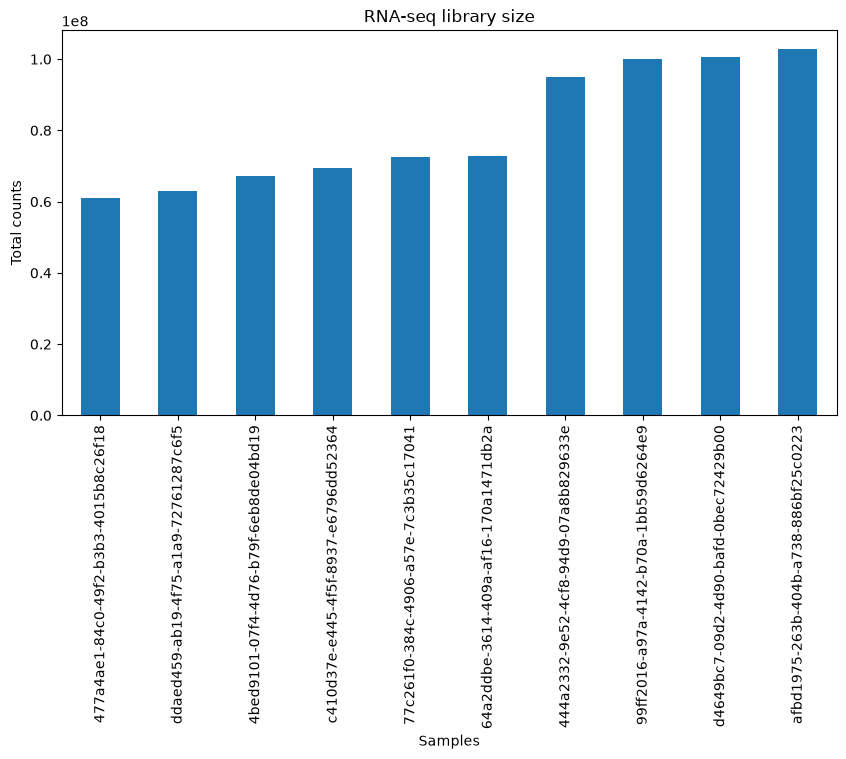

In [16]:
#Plot library size: 
#What we want: samples with similar magnitude, no sample 10x lower than others


plt.figure(figsize=(10,5))

library_size.sort_values().plot(
    kind="bar"
)

plt.ylabel("Total counts")
plt.xlabel("Samples")
plt.title("RNA-seq library size")

plt.xticks(rotation=90)

plt.show()

In [18]:
#Add metadata labels


library_df = pd.DataFrame({
    "library_size": library_size,
    "condition": metadata.loc[
        library_size.index,
        "condition"
    ]
})

In [20]:
library_df.head()

,library_size,condition
77c261f0-384c-4906-a57e-7c3b35c17041,72523015,Tumor
99ff2016-a97a-4142-b70a-1bb59d6264e9,100122729,Tumor
d4649bc7-09d2-4d90-bafd-0bec72429b00,100464861,Tumor
afbd1975-263b-404b-a738-886bf25c0223,102929143,Tumor
444a2332-9e52-4cf8-94d9-07a8b829633e,94972676,Tumor


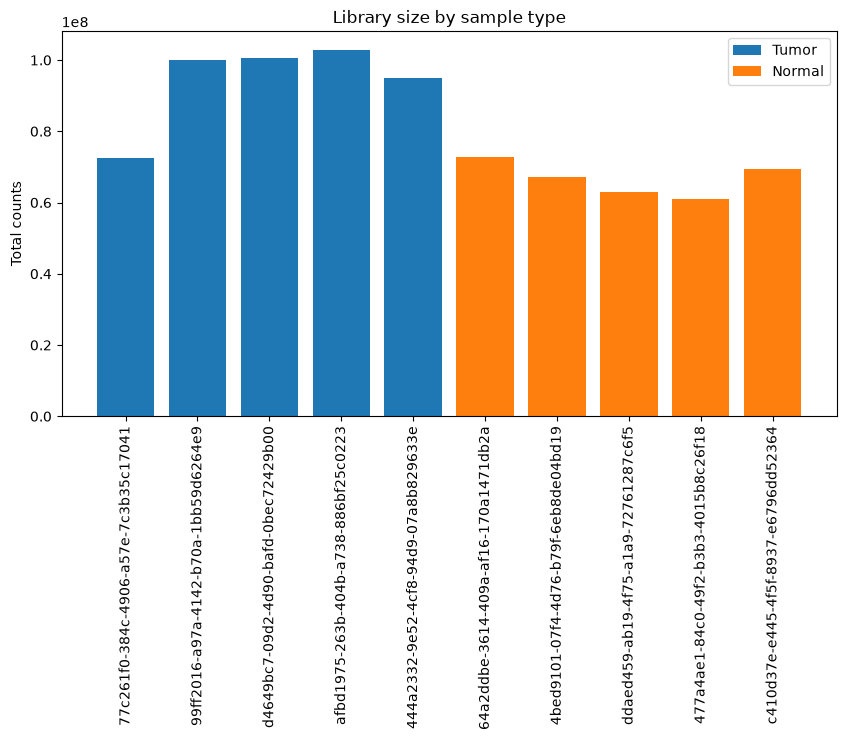

In [22]:
#Plot colored by condition


plt.figure(figsize=(10,5))


for group in library_df["condition"].unique():

    subset = library_df[
        library_df["condition"] == group
    ]

    plt.bar(
        subset.index,
        subset["library_size"],
        label=group
    )


plt.ylabel("Total counts")
plt.xticks(rotation=90)

plt.legend()

plt.title(
    "Library size by sample type"
)

plt.show()

Filter low-count genes

RNA-seq has many genes with zero or very low counts.
Remove genes that are not expressed.
Common DESeq2-style filtering:

Keep genes with:
at least 10 counts in at least 20% of samples
For your dataset:
10 samples × 0.2 = 2 samples
So:

In [25]:
min_samples = 2
min_counts = 10

In [27]:
#filter


keep = (
    (counts >= min_counts)
    .sum(axis=1)
    >= min_samples
)


filtered_counts = counts.loc[keep]

In [29]:
#check

counts.shape, filtered_counts.shape

((60620, 10), (31166, 10))

In [31]:
#Save filtered matrix:


filtered_counts.to_csv(
    PROJECT /
    "data_processed" /
    "filtered_counts_ENSG.csv"
)

PCA


Important:
Do NOT run PCA on raw counts.
Log transform first:

In [34]:
#Log transform

log_counts = np.log2(
    filtered_counts + 1
)

In [36]:
log_counts.shape

(31166, 10)

In [38]:
#Transpose:

X = log_counts.T   #PCA requires this orientation: samples × genes

In [40]:
#Run PCA

pca = PCA(
    n_components=2
)

principal_components = pca.fit_transform(X)

In [42]:
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [44]:
principal_components.shape

(10, 2)

In [46]:
pca_df = pd.DataFrame(
    principal_components,
    columns=[
        "PC1",
        "PC2"
    ],
    index=X.index
)

pca_df = pca_df.join(metadata)

pca_df.head()

,PC1,PC2,condition
77c261f0-384c-4906-a57e-7c3b35c17041,-66.793861,120.477542,Tumor
99ff2016-a97a-4142-b70a-1bb59d6264e9,123.328145,123.387201,Tumor
d4649bc7-09d2-4d90-bafd-0bec72429b00,251.972276,-12.922515,Tumor
afbd1975-263b-404b-a738-886bf25c0223,258.802953,-137.538006,Tumor
444a2332-9e52-4cf8-94d9-07a8b829633e,261.148746,45.392975,Tumor


In [48]:
#Before plotting, let's verify metadata matches the 10 samples

metadata.shape

(10, 1)

In [50]:
metadata.index.equals(X.index)

True

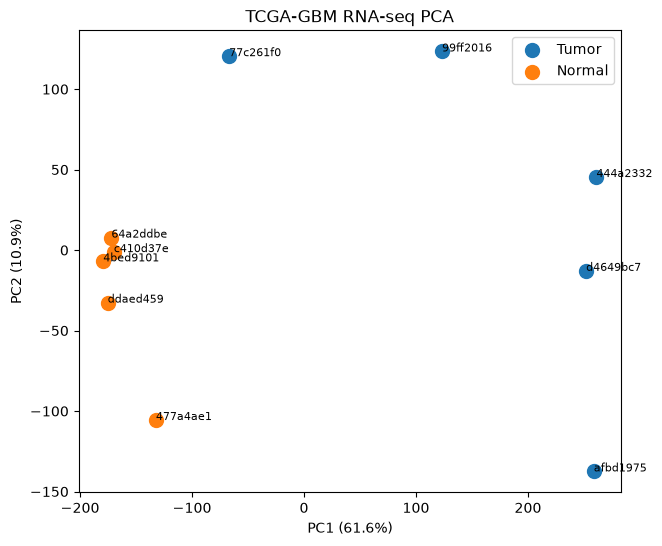

In [54]:
#plot PCA


import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for group in pca_df["condition"].unique():

    subset = pca_df[
        pca_df["condition"] == group
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=100
    )

    # label samples
    for sample in subset.index:
        plt.text(
            subset.loc[sample,"PC1"],
            subset.loc[sample,"PC2"],
            sample[:8],
            fontsize=8
        )


plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title(
    "TCGA-GBM RNA-seq PCA"
)

plt.legend()

plt.show()

In [56]:
pca.explained_variance_ratio_

array([0.61559583, 0.10897265])

For this dataset:
Normal samples should cluster together
Tumor samples should cluster separately


Hierarchical clustering
PCA is useful, but clustering gives another view.


In [60]:
X.head()

gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000288658,ENSG00000288663,ENSG00000288667,ENSG00000288670,ENSG00000288674,ENSG00000288675,N_ambiguous,N_multimapping,N_noFeature,N_unmapped
77c261f0-384c-4906-a57e-7c3b35c17041,11.195987,10.848623,9.245553,8.413628,9.727920,10.198445,10.511753,11.041659,10.412570,9.453271,...,7.228819,5.285402,0.000000,8.335390,1.000000,6.442943,22.664707,21.985251,21.205139,22.306599
99ff2016-a97a-4142-b70a-1bb59d6264e9,10.598983,10.205793,9.548822,8.764872,8.693487,10.264443,10.091435,10.711667,10.075479,8.654636,...,5.392317,3.700440,2.807355,8.523562,3.000000,5.584963,23.813064,24.421488,23.219488,23.121638
d4649bc7-09d2-4d90-bafd-0bec72429b00,11.519145,9.575539,9.893302,8.791163,9.479780,12.778077,10.121534,11.371232,9.987264,9.642052,...,2.807355,5.392317,3.169925,9.513728,4.247928,4.169925,23.181459,23.510150,24.374603,22.726959
afbd1975-263b-404b-a738-886bf25c0223,11.241387,9.403012,9.447083,8.511753,8.285402,8.738092,10.695228,9.359750,9.964341,4.954196,...,2.584963,4.906891,3.700440,6.918863,2.321928,4.807355,23.944025,24.310338,23.952721,22.522207
444a2332-9e52-4cf8-94d9-07a8b829633e,11.178042,10.049849,10.057992,9.614710,9.285402,10.405141,9.955650,11.094078,10.454299,7.721099,...,2.321928,5.426265,4.523562,8.214319,4.392317,4.700440,22.828704,23.093950,24.843391,22.008184


In [62]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(
    X,
    method="ward"
)

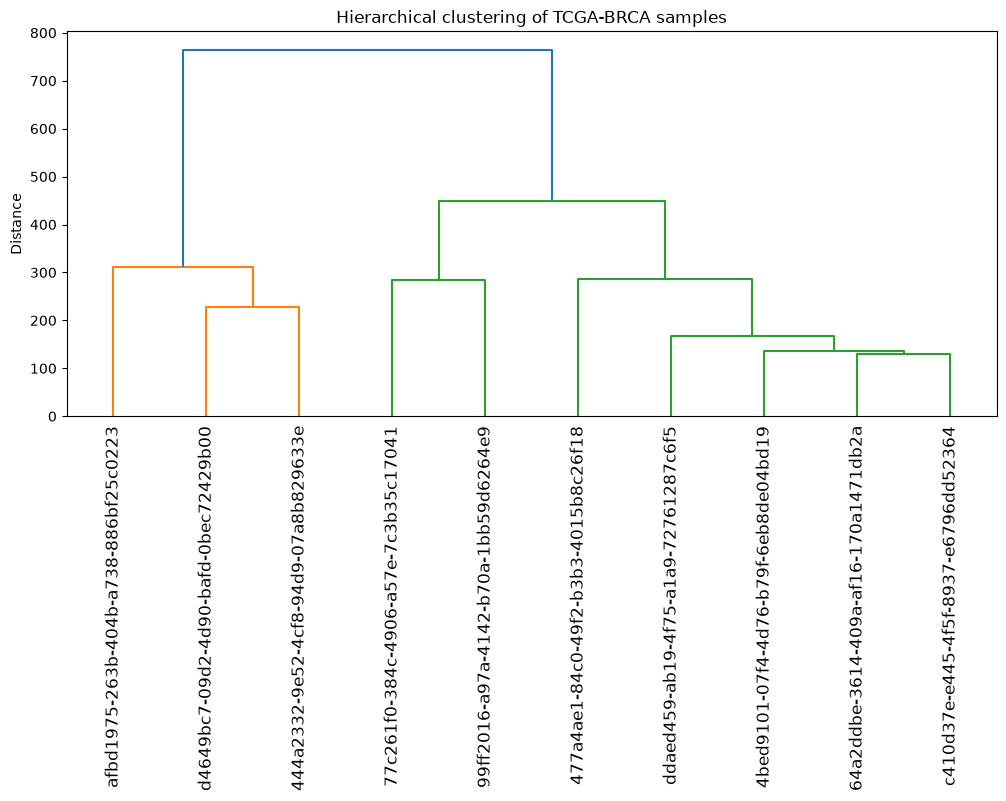

In [64]:
plt.figure(figsize=(12,5))

dendrogram(
    linked,
    labels=X.index,
    leaf_rotation=90
)

plt.title(
    "Hierarchical clustering of TCGA-BRCA samples"
)

plt.ylabel(
    "Distance"
)

plt.show()